In [13]:
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [30]:
def plot_group_comparison(df, metric, group_col="group", conditions=["EO", "EC"], remove_outlier=True):
    """
    Plot comparison of a metric between two groups under multiple conditions.

    Args:
        df (pd.DataFrame): The dataframe containing the data.
        metric (str): The metric column to compare.
        group_col (str): Column name for grouping (e.g., 'group', 'sex').
        conditions (list): List of conditions to compare (default: ['EO', 'EC']).
        remove_outlier (bool): Whether to remove outliers using IQR method (default: True).
    """
    df = df[df[group_col] != "unknown"]
    groups = df[group_col].unique()
    
    
    p_values = {}
    plot_data = []

    # 外れ値除去関数
    def _remove_outliers(data):
        q1 = np.percentile(data, 25)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return data[(data >= lower) & (data <= upper)]

    # データ整理と統計
    for cond in conditions:
        sub_df = df[df["condition"] == cond]
        cond_data = []
        for group in groups:
            values = sub_df[sub_df[group_col] == group][metric].values
            if remove_outlier:
                values = _remove_outliers(values)
            cond_data.append(values)
            plot_data.append(values)
        # Mann-Whitney U test
        stat, p = mannwhitneyu(cond_data[0], cond_data[1], alternative='two-sided')
        p_values[cond] = p

    # プロット
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=plot_data, palette="Set2")
    sns.swarmplot(data=plot_data, color="black", alpha=0.6)

    # x軸ラベル
    plot_labels = [f"{cond}-{group}" for cond in conditions for group in groups]
    plt.xticks(range(len(plot_labels)), plot_labels)

    # タイトルにp値
    p_text = ", ".join([f"{cond}: p={p_values[cond]:.4f}" for cond in conditions])
    plt.title(f"{metric} ({group_col}, outliers removed)\n{p_text}")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

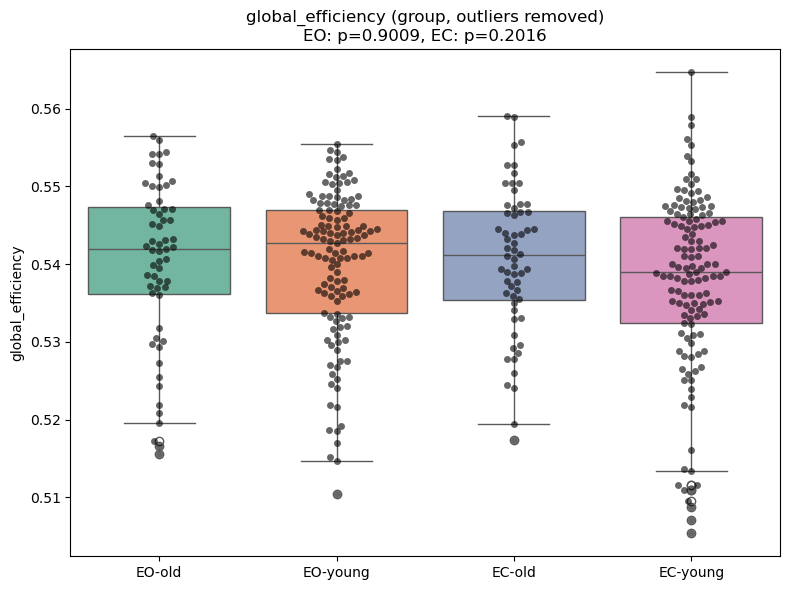

In [31]:
# === CSV読込 ===
df = pd.read_csv("D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\results\\connectivity\\global_network_metrics.csv")

plot_group_comparison(df, metric="global_efficiency", group_col="group")

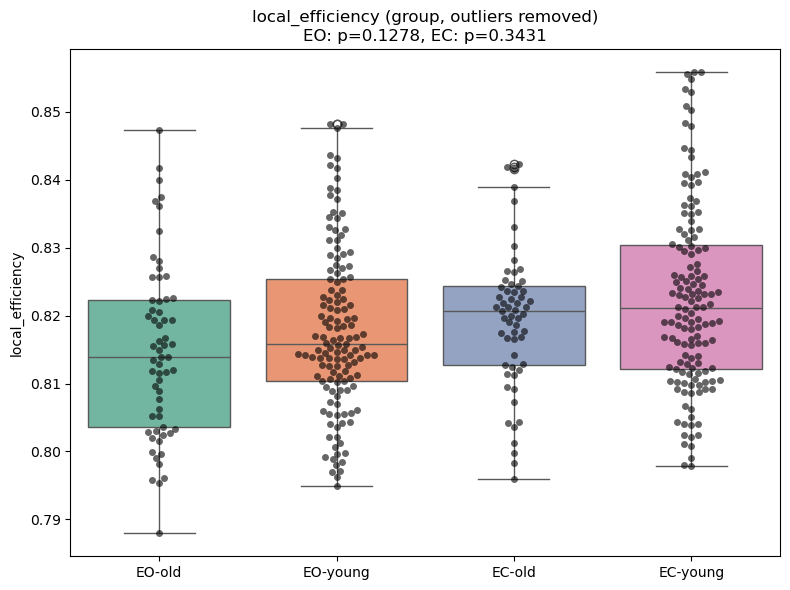

In [32]:
plot_group_comparison(df, metric="local_efficiency", group_col="group")

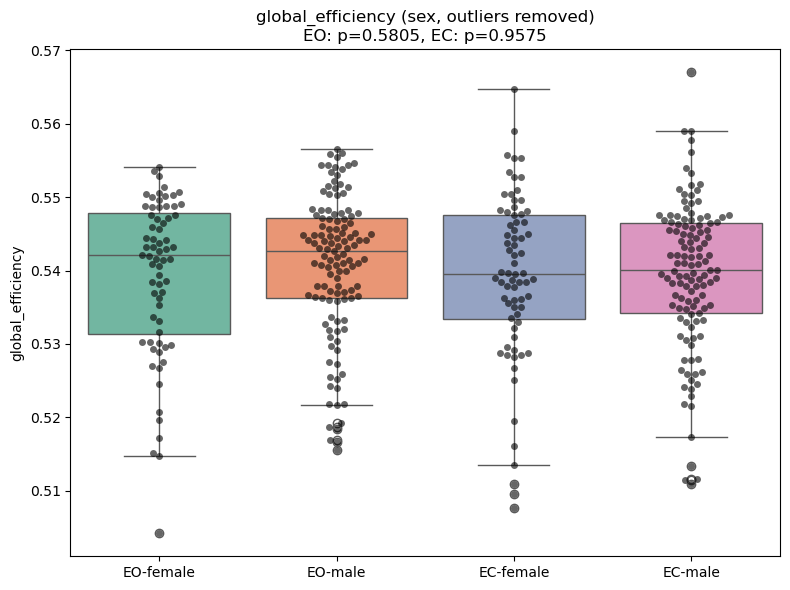

In [33]:
plot_group_comparison(df, metric="global_efficiency", group_col="sex")

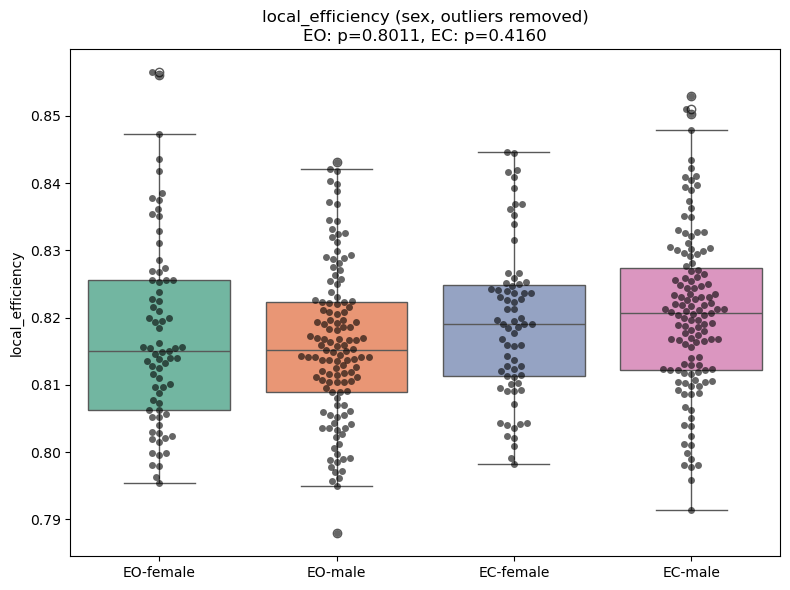

In [34]:
plot_group_comparison(df, metric="local_efficiency", group_col="sex")

In [35]:
from scipy.stats import shapiro
stat, p = shapiro(young)
print("Shapiro-Wilk test:", p)

Shapiro-Wilk test: 0.27158575506541494


In [6]:
stat, p = shapiro(old)
print("Shapiro-Wilk test:", p)

Shapiro-Wilk test: 0.9938707100937793


In [8]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(young, old, equal_var=False)
print(p)

0.19482943499681937


In [39]:
wst_df = pd.read_csv("D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\EEG_MPILMBB_LEMON\Behavioural_Data_MPILMBB_LEMON\Cognitive_Test_Battery_LEMON\WST\WST.csv")
wst_df = wst_df.sort_values(by="Unnamed: 0").reset_index(drop=True)
wst_df.head()

<>:1: SyntaxWarning: invalid escape sequence '\F'
<>:1: SyntaxWarning: invalid escape sequence '\F'
C:\Users\sFukuyama\AppData\Local\Temp\8\ipykernel_54136\2842911513.py:1: SyntaxWarning: invalid escape sequence '\F'
  wst_df = pd.read_csv("D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\data\EEG_MPILMBB_LEMON\Behavioural_Data_MPILMBB_LEMON\Cognitive_Test_Battery_LEMON\WST\WST.csv")


,Unnamed: 0,WST_1,WST_2,WST_3,WST_4,WST_5
0,sub-032301,29,-0.19,97,98,NaN
1,sub-032302,28,-0.32,95,97,NaN
2,sub-032303,31,0.10,101,101,NaN
3,sub-032304,34,0.67,110,107,NaN
4,sub-032305,32,0.26,104,103,NaN


In [ ]:
from scipy.stats import spearmanr

def analyze_connectivity_vs_wst(connectivity_csv, wst_csv, metric="global_efficiency", condition="EO"):
    """
    EEGコネクティビティ指標とWST（語彙知能）スコアの関連を解析する。

    Args:
        connectivity_csv (str): グローバルネットワーク指標CSVファイルのパス
        wst_csv (str): WSTデータのCSVファイルのパス
        metric (str): 解析対象のネットワーク指標（例："global_efficiency"）
        condition (str): 対象条件（"EO"または"EC"）

    Returns:
        pd.DataFrame: 結合済みデータ
    """
    # === データ読み込み ===
    conn_df = pd.read_csv(connectivity_csv)
    wst_df = pd.read_csv(wst_csv)

    # # 不要列削除
    # if "Unnamed: 0" in wst_df.columns:
    #     wst_df = wst_df.drop(columns=["Unnamed: 0"])

    # conn_df の被験者IDリスト
    ids = conn_df["subject_id"].unique()

    # 被験者ID列名を統一
    wst_df = wst_df.rename(columns={"Unnamed: 0": "subject_id"})

    # 条件指定
    conn_df = conn_df[conn_df["condition"] == condition]

    # wst_df から該当IDのみ抽出
    wst_matched = wst_df[wst_df["subject_id"].isin(ids)]

    # 欠損値除去
    merged = wst_matched.dropna(subset=["WST_3", metric])

    # === 相関解析（Spearman） ===
    rho, pval = spearmanr(merged[metric], merged["WST_3"])
    print(f"\n{condition} - {metric} vs WST_3:")
    print(f"Spearman ρ = {rho:.3f}, p = {pval:.4f} (n={len(merged)})")

    # === 散布図 ===
    plt.figure(figsize=(6, 5))
    sns.regplot(x=metric, y="WST_3", data=merged, scatter_kws={"s": 50, "alpha": 0.7})
    plt.title(f"{condition}: {metric} vs WST_3\nSpearman ρ={rho:.3f}, p={pval:.4f}")
    plt.tight_layout()
    plt.show()

    return merged

# 使用例
merged_df = analyze_connectivity_vs_wst(
    connectivity_csv="D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\results\\connectivity\\global_network_metrics.csv",
    wst_csv="D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\EEG_MPILMBB_LEMON\\Behavioural_Data_MPILMBB_LEMON\\Cognitive_Test_Battery_LEMON\\WST\\WST.csv",
    metric="global_efficiency",
    condition="EO"
)

ValueError: You are trying to merge on object and int64 columns for key 'subject_id'. If you wish to proceed you should use pd.concat

In [ ]:
import os
import pandas as pd
import sys
# ディレクトリのパス
raw_dir = r"D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\raw"
preproc_dir = r"D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\data\\EEG_MPILMBB_LEMON\\EEG_Preprocessed_BIDS_ID\\EEG_Preprocessed"

# 除外する被験者ID
exclude_ids = {"sub-032313", "sub-032410", "sub-032428"}

# ディレクトリ内の被験者IDを取得
raw_subjects = sorted([
    d for d in os.listdir(raw_dir)
    if d.startswith("sub-") and os.path.isdir(os.path.join(raw_dir, d)) and d not in exclude_ids
])

preproc_subjects = sorted([
    d for d in os.listdir(preproc_dir)
    if d.startswith("sub-") and os.path.isdir(os.path.join(preproc_dir, d)) and d not in exclude_ids
])

# 件数確認
if len(raw_subjects) != len(preproc_subjects):
    print("エラー: raw_dir と preproc_dir の被験者数が一致していません。")
    print(f" raw_dir: {len(raw_subjects)} 件")
    print(f" preproc_dir: {len(preproc_subjects)} 件")
    sys.exit(1)

# 対応表作成
mapping_df = pd.DataFrame({
    "raw_id": raw_subjects,
    "preprocessed_id": preproc_subjects
})

# CSVとして出力
output_csv = r"D:\FY2025\Fukuyama\work place\eeg-mri-aging-analysis\subject_id_mapping.csv"
mapping_df.to_csv(output_csv, index=False)

print(f"対応表を作成しました: {output_csv}")
print(f" - 登録件数: {len(mapping_df)} 件")

❌ エラー: raw_dir と preproc_dir の被験者数が一致していません。
 raw_dir: 212 件
 preproc_dir: 201 件


SystemExit: 1

d:\FY2025\Fukuyama\Programs\anaconda3\envs\mne\Lib\site-packages\IPython\core\interactiveshell.py:3675: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
def analyze_connectivity_vs_wst(connectivity_csv, wst_csv, metric="global_efficiency", condition="EO"):
    """
    EEGコネクティビティ指標とWST（語彙知能）スコアの関連を解析する。
    被験者IDによる対応づけは行わず、行順で単純に結合する。

    Args:
        connectivity_csv (str): グローバルネットワーク指標CSVファイルのパス
        wst_csv (str): WSTデータのCSVファイルのパス
        metric (str): 解析対象のネットワーク指標（例："global_efficiency"）
        condition (str): 対象条件（"EO"または"EC"）

    Returns:
        pd.DataFrame: 結合済みデータ
    """

    # === データ読み込み ===
    conn_df = pd.read_csv(connectivity_csv)
    wst_df = pd.read_csv(wst_csv)

    # === 条件抽出 ===
    conn_df = conn_df[conn_df["condition"] == condition].reset_index(drop=True)
    wst_df = wst_df.reset_index(drop=True)

    # === 行数を短い方に合わせる ===
    n = min(len(conn_df), len(wst_df))
    if len(conn_df) != len(wst_df):
        print(f"行数が異なります: conn_df={len(conn_df)}, wst_df={len(wst_df)} → {n}行に揃えます")

    conn_df = conn_df.iloc[:n]
    wst_df = wst_df.iloc[:n]

    # === 結合 ===
    merged = pd.concat([conn_df, wst_df], axis=1)

    # === 欠損値除去 ===
    if "WST_3" not in merged.columns:
        raise ValueError("WSTデータに 'WST_3' 列が存在しません。")

    merged = merged.dropna(subset=["WST_3", metric])

    # === 相関解析（Spearman） ===
    rho, pval = spearmanr(merged[metric], merged["WST_3"])
    print(f"\n{condition} - {metric} vs WST_3:")
    print(f"Spearman ρ = {rho:.3f}, p = {pval:.4f} (n={len(merged)})")

    # === 散布図 ===
    plt.figure(figsize=(6, 5))
    sns.regplot(x=metric, y="WST_3", data=merged, scatter_kws={"s": 50, "alpha": 0.7})
    plt.title(f"{condition}: {metric} vs WST_3\nSpearman ρ={rho:.3f}, p={pval:.4f}")
    plt.tight_layout()
    plt.show()

    return merged

⚠️ 行数が異なります: conn_df=206, wst_df=228 → 206行に揃えます

EO - global_efficiency vs WST_3:
Spearman ρ = -0.015, p = 0.8298 (n=206)


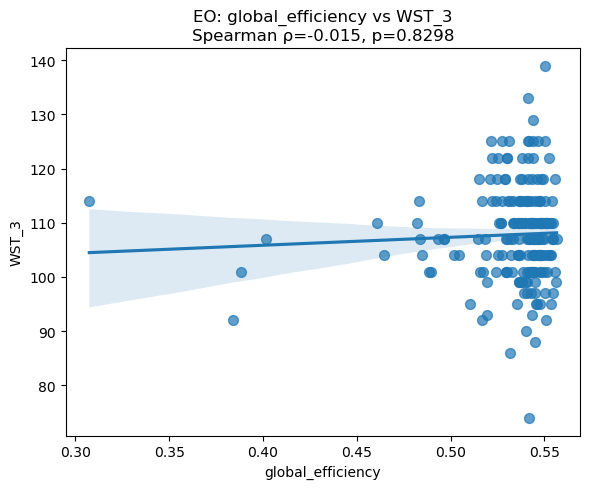

In [41]:
merged_df = analyze_connectivity_vs_wst(
    connectivity_csv="D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\results\\connectivity\\global_network_metrics.csv",
    wst_csv="D:\\FY2025\\Fukuyama\\work place\\eeg-mri-aging-analysis\\data\\EEG_MPILMBB_LEMON\\Behavioural_Data_MPILMBB_LEMON\\Cognitive_Test_Battery_LEMON\\WST\\WST.csv",
    metric="global_efficiency",
    condition="EO"
)